In [22]:
import pandas as pd
import numpy as np

# Apni file ka naam yahan daalo (jo bhi naam hai upload ki hui file ka)
df = pd.read_csv('Titanic-Dataset.csv')

# Data Quality Report
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()

Shape: (891, 10)

Column dtypes:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
dtype: object

Missing values per column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

Duplicate rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500


In [23]:
# Age ki missing values ko median se fill karo (average se better hai, outliers se safe rehta hai)
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

print("Median Age used:", median_age)
print("\nMissing values after cleaning:\n", df.isnull().sum())

Median Age used: 28.0

Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
dtype: int64


### Missing Data Handling: Age Column
Age column mein 177 missing values thi (~20% data). In values ko **median**
se fill kiya gaya, average (mean) ke bajaye, kyunki median outliers se
kam affect hota hai aur zyada realistic estimate deta hai age jaisi
skewed distribution ke liye.

In [24]:
# Duplicate rows dobara check karo (already 0 the, but confirm kar lete hain)
print("Duplicate rows:", df.duplicated().sum())

# Data types check karo aur zaroori columns ko sahi type mein convert karo
# 'Survived' aur 'Pclass' categories hain, inko category type bana sakte hain
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')

print("\nUpdated data types:\n", df.dtypes)

Duplicate rows: 0

Updated data types:
 PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
dtype: object


Number of outliers in Fare: 116
Lower bound: -26.724 | Upper bound: 65.6344


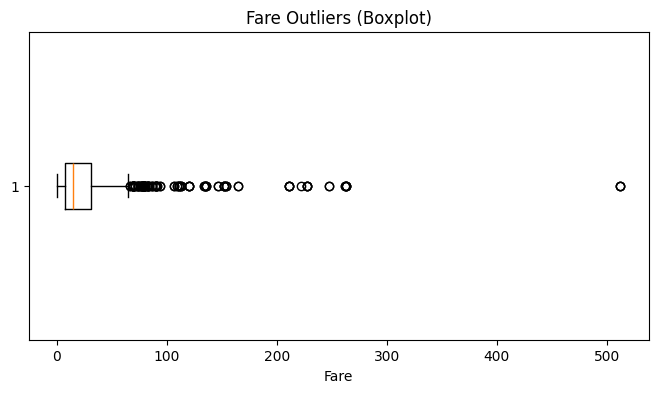

In [25]:
import matplotlib.pyplot as plt

# Fare column mein outliers dhoondo IQR method se
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print("Number of outliers in Fare:", outliers.shape[0])
print("Lower bound:", lower_bound, "| Upper bound:", upper_bound)

# Boxplot bana ke visually dekho
plt.figure(figsize=(8,4))
plt.boxplot(df['Fare'], vert=False)
plt.title('Fare Outliers (Boxplot)')
plt.xlabel('Fare')
plt.show()

### Outlier Handling: Fare Column
IQR method se Fare column mein 116 outliers mile (mostly high-value
first-class tickets). Inhe delete nahi kiya gaya kyunki ye genuine data
hai, errors nahi. Iske bajaye "capping" technique use ki gayi — extreme
values ko upper bound (65.63) tak limit kiya gaya, taaki analysis
skewed na ho lekin koi data bhi na khoye.

Before capping - Max Fare: 512.3292
After capping - Max Fare: 65.6344


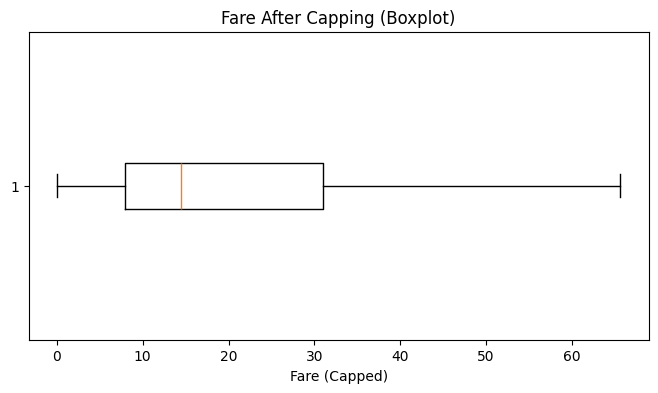

In [26]:
# Fare ko cap karo upper bound tak (outliers ko retain karte hain but extreme values control karte hain)
df['Fare_capped'] = df['Fare'].clip(upper=upper_bound)

print("Before capping - Max Fare:", df['Fare'].max())
print("After capping - Max Fare:", df['Fare_capped'].max())

# Comparison boxplot
plt.figure(figsize=(8,4))
plt.boxplot(df['Fare_capped'], vert=False)
plt.title('Fare After Capping (Boxplot)')
plt.xlabel('Fare (Capped)')
plt.show()

In [27]:
# Before vs After Cleaning Summary
summary = pd.DataFrame({
    'Metric': ['Null Count (Age)', 'Duplicate Rows', 'Max Fare', 'Total Rows'],
    'Before Cleaning': [177, 0, 512.33, 891],
    'After Cleaning': [df['Age'].isnull().sum(), df.duplicated().sum(), df['Fare_capped'].max(), df.shape[0]]
})

print(summary)

             Metric  Before Cleaning  After Cleaning
0  Null Count (Age)           177.00          0.0000
1    Duplicate Rows             0.00          0.0000
2          Max Fare           512.33         65.6344
3        Total Rows           891.00        891.0000


In [28]:
# Cleaned dataset ko naye CSV file mein save karo
df.to_csv('Titanic_Cleaned.csv', index=False)
print("File saved successfully!")

# File download karne ke liye
from google.colab import files
files.download('Titanic_Cleaned.csv')

File saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

Is task mein humne ek messy Titanic dataset ko systematically clean
kiya — missing values (Age) ko median se fill kiya, Fare column ke
outliers ko IQR method se detect karke cap kiya, aur data types ko
correct kiya (categorical columns). Before-after summary table se
confirm hota hai ki dataset ab analysis-ready hai, bina kisi data loss
ke. Final cleaned dataset ko 'Titanic_Cleaned.csv' ke naam se save
kiya gaya hai.